# **1. Kredensial & Instalasi Library**
Di sini kita menginstal semua dependensi dan memunculkan chatbox agar kredensial Kaggle dan Hugging Face aman.

---

In [1]:
!pip install -q transformers datasets evaluate accelerate huggingface_hub kaggle
from huggingface_hub import notebook_login
import os
import getpass

print("1. Masukkan Access Token Hugging Face kamu (tipe Write):")
notebook_login()

print("\n2. Mengatur Autentikasi Kaggle...")
# Meminta input dari pengguna melalui chatbox
kaggle_user = input("Masukkan Username Kaggle kamu: ")
kaggle_key = getpass.getpass("Masukkan API Key Kaggle kamu: ")

# Mendaftarkan input ke environment variables agar API Kaggle bisa berjalan
os.environ['KAGGLE_USERNAME'] = kaggle_user
os.environ['KAGGLE_KEY'] = kaggle_key

print("✅ Autentikasi Kaggle dan Hugging Face berhasil disiapkan dengan aman!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00
1. Masukkan Access Token Hugging Face kamu (tipe Write):


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



2. Mengatur Autentikasi Kaggle...
Masukkan Username Kaggle kamu: ripanripan
Masukkan API Key Kaggle kamu: ··········
✅ Autentikasi Kaggle dan Hugging Face berhasil disiapkan dengan aman!


# **2. Unduh & Muat Dataset dari Kaggle**
Kita akan meminta input link/path dataset Kaggle secara langsung, mengunduhnya, dan membaca strukturnya menggunakan format imagefolder.

---

Masukkan format <username>/<nama-dataset> dari Kaggle: donaasu/mukhbir-project-dataset

⏳ Sedang mengunduh dataset: donaasu/mukhbir-project-dataset dari Kaggle...
Dataset URL: https://www.kaggle.com/datasets/donaasu/mukhbir-project-dataset
License(s): other
100% 447M/447M [00:08<00:00, 53.1MB/s]

⏳ Memuat dataset ke dalam format Hugging Face...


Resolving data files:   0%|          | 0/37386 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]


✅ Dataset berhasil dimuat!

🔍 MELAKUKAN ANALISIS DATA (EDA)...
------------------------------
Distribusi Data pada Split 'train':
 - Fake: 18957 gambar (50.71%)
 - Real: 18429 gambar (49.29%)
Total Keseluruhan: 37386 gambar


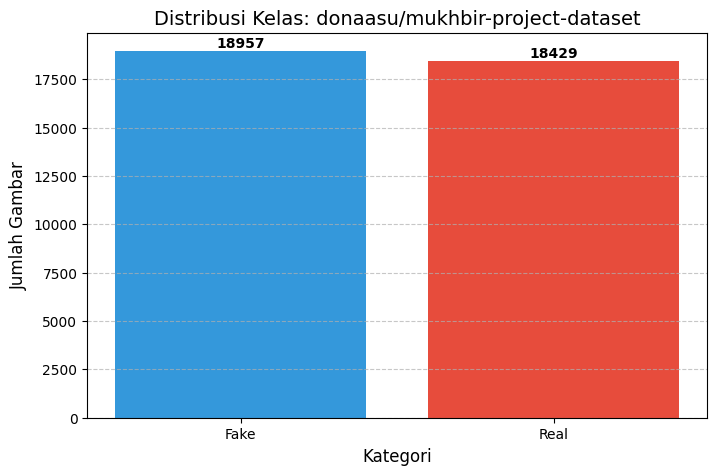

------------------------------

--- STRUKTUR DATASET AWAL ---
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 37386
    })
})


In [2]:
from datasets import load_dataset
import shutil
import matplotlib.pyplot as plt
from collections import Counter

# Meminta input path dataset Kaggle
nama_dataset_kaggle = input("Masukkan format <username>/<nama-dataset> dari Kaggle: ")

# Membersihkan folder lama jika ada
if os.path.exists("./dataset_mentah"):
    shutil.rmtree("./dataset_mentah")

print(f"\n⏳ Sedang mengunduh dataset: {nama_dataset_kaggle} dari Kaggle...")
!kaggle datasets download -d $nama_dataset_kaggle -p ./dataset_mentah --unzip

print("⏳ Memuat dataset ke dalam format Hugging Face...")
dataset = load_dataset("imagefolder", data_dir="./dataset_mentah")

print("\n✅ Dataset berhasil dimuat!")

# --- BAGIAN EDA (EXPLORATORY DATA ANALYSIS) ---
print("\n🔍 MELAKUKAN ANALISIS DATA (EDA)...")
print("-" * 30)

# 1. Ambil informasi label
split_utama = "train" if "train" in dataset else list(dataset.keys())[0]
label_names = dataset[split_utama].features["label"].names
all_labels = dataset[split_utama]["label"]

# 2. Hitung jumlah tiap kategori
hitung_data = Counter(all_labels)
distribusi = {label_names[i]: hitung_data[i] for i in range(len(label_names))}

# 3. Tampilkan hasil dalam bentuk tabel sederhana
print(f"Distribusi Data pada Split '{split_utama}':")
for kategori, jumlah in distribusi.items():
    persentase = (jumlah / len(all_labels)) * 100
    print(f" - {kategori}: {jumlah} gambar ({persentase:.2f}%)")
print(f"Total Keseluruhan: {len(all_labels)} gambar")

# 4. Visualisasi dengan Grafik Batang (Bar Chart)
plt.figure(figsize=(8, 5))
colors = ['#3498db', '#e74c3c'] # Biru untuk Real, Merah untuk Fake (atau sebaliknya)
plt.bar(distribusi.keys(), distribusi.values(), color=colors[:len(distribusi)])

plt.title(f"Distribusi Kelas: {nama_dataset_kaggle}", fontsize=14)
plt.xlabel("Kategori", fontsize=12)
plt.ylabel("Jumlah Gambar", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan label angka di atas batang
for i, v in enumerate(distribusi.values()):
    plt.text(i, v + (max(distribusi.values())*0.01), str(v), ha='center', fontweight='bold')

plt.show()
print("-" * 30)
# --- SELESAI EDA ---

print("\n--- STRUKTUR DATASET AWAL ---")
print(dataset)

# Path dataset Kaggle (Real vs AI) yang dapat dicoba:
# ayushmandatta1/deepdetect-2025 [~112.000 gambar | Dataset AI vs Real Terbaru 2025]
# birdy654/cifake-real-and-ai-generated-synthetic-images [120.000 gambar | Resolusi Rendah 32x32, Cocok untuk Uji Coba/Sanity Check Kode]
# awsaf49/artifact-dataset [2,5 Juta gambar | Paling Komprehensif & Skala Masif (The Gold Standard)]
# malaxmels/ai-detection-dataset [~56.600 gambar | Kualitas Resolusi Tinggi & Fokus Modern Diffusion (Sumber Asli: tristanzhang32/ai-generated-images-vs-real-images)]
# shreyasraghav/shutterstock-dataset-for-ai-vs-human-gen-image [105.000 gambar | Dataset "Pairing" (Mencegah Dataset Bias)]
# rhythmghai/ai-vs-real-images-dataset [995 gambar | Photorealism vs Unsplash (Cocok untuk Fine-Tuning Cepat)]
# donaasu/mukhbir-project-dataset [~37.400 gambar | Kualitas Super Bersih (Hasil Kurasi Manual)]

# **3. Pemrosesan Gambar & Sampling Full Balanced**
Bagian ini untuk tetap menjaga aturan emas Machine Learning: kelasnya harus mutlak seimbang (50:50) agar model tidak bias (lebih condong menebak satu kelas saja).

Untuk menggunakan seluruh data secara maksimal namun tetap dijamin 100% seimbang, kita harus menghitung jumlah masing-masing kelas terlebih dahulu, lalu mengambil angka terkecil (minimum) dari keduanya sebagai batas acuan.

---

In [3]:
# # KODE ALTERNATIF 1 SELURUH DATASET:
# from transformers import AutoImageProcessor

# # 1. Inisialisasi Processor
# checkpoint_model = "google/vit-base-patch16-224-in21k"
# image_processor = AutoImageProcessor.from_pretrained(checkpoint_model)

# def proses_gambar(batch):
#     # Konversi ke RGB & ubah ke format tensor yang dipahami ViT
#     inputs = image_processor([gambar.convert("RGB") for gambar in batch['image']], return_tensors='pt')
#     inputs['labels'] = batch['label']
#     return inputs

# # 2. Pengecekan dan Pemecahan Dataset
# # Jika dataset mentah belum terbagi, kita bagi 90:10
# if "test" not in dataset:
#     print("🛠️ Memecah dataset menjadi Train (90%) dan Test (10%)...")
#     # Menggunakan stratify agar proporsi label tetap terjaga meski tidak 50:50
#     dataset_pecah = dataset["train"].train_test_split(test_size=0.1, seed=42, stratify_by_column="label")
# else:
#     dataset_pecah = dataset

# nama_label = dataset_pecah["train"].features["label"].names
# print(f"✅ Kategori ditemukan: {nama_label}")

# # 3. Menerapkan Transformasi ke SELURUH Dataset
# print("🚀 Menyiapkan seluruh data untuk pelatihan (tanpa pemotongan)...")

# # Kita langsung gunakan seluruh data dari hasil split tanpa filter/select
# train_subset = dataset_pecah["train"].shuffle(seed=42).with_transform(proses_gambar)
# test_subset = dataset_pecah["test"].shuffle(seed=42).with_transform(proses_gambar)

# # 4. Ringkasan Akhir
# print(f"\n✅ Total Data Train: {len(train_subset)} gambar")
# print(f"✅ Total Data Test: {len(test_subset)} gambar")
# print("⚠️ Catatan: Model akan belajar dari jumlah data asli apa adanya.")

In [4]:
# KODE ALTERNATIF 2 (DATASET INBALANCE TO BALANCE):
from transformers import AutoImageProcessor
from datasets import concatenate_datasets
import torch

# 1. Inisialisasi Processor
checkpoint_model = "google/vit-base-patch16-224-in21k"
image_processor = AutoImageProcessor.from_pretrained(checkpoint_model)

def proses_gambar(batch):
    # Memastikan gambar dikonversi ke RGB sebelum diproses oleh ViT
    inputs = image_processor([gambar.convert("RGB") for gambar in batch['image']], return_tensors='pt')
    inputs['labels'] = batch['label']
    return inputs

# 2. Pemecahan Dataset (jika belum ada split test)
if "test" not in dataset:
    print("🛠️ Memecah dataset menjadi Train (90%) dan Test (10%)...")
    dataset_pecah = dataset["train"].train_test_split(test_size=0.1, seed=42, stratify_by_column="label")
else:
    dataset_pecah = dataset

print(f"📊 Kategori: {dataset_pecah['train'].features['label'].names}")

def balance_my_dataset(ds_partition, name="Data"):
    print(f"⚖️ Menyeimbangkan {name}...")

    # Pisahkan berdasarkan label
    class_0 = ds_partition.filter(lambda x: x['label'] == 0, num_proc=4) # num_proc mempercepat proses
    class_1 = ds_partition.filter(lambda x: x['label'] == 1, num_proc=4)

    # Ambil jumlah minimum (contoh: jika 100k vs 110k, maka ambil 100k)
    min_size = min(len(class_0), len(class_1))

    print(f"   - Kelas 0: {len(class_0)} gambar")
    print(f"   - Kelas 1: {len(class_1)} gambar")
    print(f"   - Hasil Akhir: Masing-masing kelas diambil {min_size} gambar (Total: {min_size * 2})")

    # Potong data agar setara dan acak
    class_0_balanced = class_0.shuffle(seed=42).select(range(min_size))
    class_1_balanced = class_1.shuffle(seed=42).select(range(min_size))

    # Gabungkan kembali dan acak urutannya
    return concatenate_datasets([class_0_balanced, class_1_balanced]).shuffle(seed=42)

# 3. Eksekusi Penyeimbangan
train_balanced = balance_my_dataset(dataset_pecah["train"], "Train Set")
test_balanced = balance_my_dataset(dataset_pecah["test"], "Test Set")

# 4. Terapkan Transformasi (proses_gambar)
# Menggunakan with_transform agar hemat RAM (lazy loading)
train_subset = train_balanced.with_transform(proses_gambar)
test_subset = test_balanced.with_transform(proses_gambar)

print(f"\n✅ [SIAP] Train: {len(train_subset)} | Test: {len(test_subset)}")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


🛠️ Memecah dataset menjadi Train (90%) dan Test (10%)...
📊 Kategori: ['Fake', 'Real']
⚖️ Menyeimbangkan Train Set...


Filter (num_proc=4):   0%|          | 0/33647 [00:00<?, ? examples/s]

Filter (num_proc=4):   0%|          | 0/33647 [00:00<?, ? examples/s]

   - Kelas 0: 17061 gambar
   - Kelas 1: 16586 gambar
   - Hasil Akhir: Masing-masing kelas diambil 16586 gambar (Total: 33172)
⚖️ Menyeimbangkan Test Set...


Filter (num_proc=4):   0%|          | 0/3739 [00:00<?, ? examples/s]

Filter (num_proc=4):   0%|          | 0/3739 [00:00<?, ? examples/s]

   - Kelas 0: 1896 gambar
   - Kelas 1: 1843 gambar
   - Hasil Akhir: Masing-masing kelas diambil 1843 gambar (Total: 3686)

✅ [SIAP] Train: 33172 | Test: 3686


# **4. Konfigurasi Model & Parameter Pelatihan**
Kamus label (id2label) dibuat dinamis berdasarkan dataset Kaggle yang kamu masukkan, dan fp16=True ditambahkan untuk efisiensi komputasi hardware (GPU T4).

---

In [5]:
import evaluate
import numpy as np
from transformers import AutoModelForImageClassification, TrainingArguments, DefaultDataCollator

akurasi = evaluate.load("accuracy")

def hitung_metrik(eval_pred):
    tebakan, label_asli = eval_pred
    tebakan_final = np.argmax(tebakan, axis=1)
    return akurasi.compute(predictions=tebakan_final, references=label_asli)

nama_label = dataset_pecah['train'].features['label'].names
# -----------------------------------

# Memetakan nama label secara dinamis
id2label = {str(i): label for i, label in enumerate(nama_label)}
label2id = {label: str(i) for i, label in enumerate(nama_label)}

# Inisialisasi arsitektur Model
model = AutoModelForImageClassification.from_pretrained(
    checkpoint_model,
    num_labels=len(nama_label),
    id2label=id2label,
    label2id=label2id,
)

# Pengaturan strategi pelatihan (dioptimalkan untuk GPU T4 di Colab)
aturan_latihan = TrainingArguments(
    output_dir="./hasil_detektor_ai",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    warmup_steps=300,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=True,
    hub_model_id="Ripanrz/detektor-ai-v1.1",
    fp16=True, # Mempercepat proses training dan menghemat memori GPU
    #report_to="wandb"                # Bisa diganti "wandb" jika ingin tracking grafik online
)

# Membantu menyusun batch data sebelum masuk ke model
data_collator = DefaultDataCollator()

print("✅ Model dan aturan pelatihan berhasil dikonfigurasi!")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model dan aturan pelatihan berhasil dikonfigurasi!


# **5. Eksekusi Pelatihan & Unggah ke Hugging Face Hub**
Proses training dieksekusi dan hasil akhirnya langsung didorong ke repository Hugging Face kamu.

---

In [6]:
from transformers import Trainer

pelatih = Trainer(
    model=model,
    args=aturan_latihan,
    train_dataset=train_subset,
    eval_dataset=test_subset,
    processing_class=image_processor,
    compute_metrics=hitung_metrik,
)

print("🚀 Memulai proses Training... Pastikan Runtime Colab menggunakan GPU T4!")
pelatih.train()

print("\n⬆️ Mengunggah model ke Hugging Face Hub...")
pelatih.push_to_hub()
print("🎉 Selamat! Model detektor AI kamu berhasil di-deploy ke Hugging Face Hub!")

🚀 Memulai proses Training... Pastikan Runtime Colab menggunakan GPU T4!


Epoch,Training Loss,Validation Loss,Accuracy
1,0.212780,0.197747,0.919967
2,0.089333,0.143952,0.948182
3,0.055822,0.136846,0.954693
4,0.016614,0.172030,0.960119


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ktor_ai/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

  ...ktor_ai/model.safetensors:  42%|####1     |  144MB /  343MB            

🎉 Selamat! Model detektor AI kamu berhasil di-deploy ke Hugging Face Hub!
